In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from lib.readwav import *

# Classificazione di note prodotte da un organo


In [2]:
# Questa cella è un primo esempio di lettura di segnale audio, al momento commentata per alleggerire l'esecuzione.


#####################à Secondo me è più chiaro se nel notebook queste celle di vecchi test ce le lasciamo, soprattutto perché
# anche se non ci servono più, il codice al loro interno funziona ancora come descritto, e quindi è più facile se questi sanity
# check ce li lasciamo scritti. Tanto, tutti commentati, non dovrebbero darvi fastidio. Personalmente trovo utile lasciare queste celle
# anche solo per le spiegazioni passo passo che lascio innanzitutto a me stesso ############################################


# Per leggere i segnali audio, useremo la funzione readwav già precedentemente scritta e fornitaci.
# Questa funzione si trova nel file readwav.py all'interno della cartella lib. Si usa come segue:
#filename = "./wav_files/note_104.wav"
#rate, note = readwav(filename)
# Nella maniera in cui è implementata, readwav restituisce due cose: un float contenente il sampling rate del segnale,
# e un array contenente i dati veri e propri, ossia l'intensità del segnale nel tempo.
# In particolare, la funzione tratta ugualmente wav in 8bit oppure 24bit, e l'array ha una sola colonna se il segnale è mono,
# oppure due colonne se il segnale è stereo (noi useremo sempre uno solo dei due canali).

# Per trattare dunque l'array di dati, innanzitutto generiamo i time step corrispondenti:
#time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) # Fin qui, time è solo un indice contatore,
#time /= rate
# mentre così time contiene ora il tempo fisico.

# Possiamo plottare il segnale per farci un'idea di com'è fatto. Nel primo pannello rappresentiamo tutto il segnale,
# mentre nel secondo una porzione zoomata al centro per riuscire a vedere i singoli periodi.
#figure, axes = plt.subplots(2, 1, figsize=(12, 7))
#ax = axes[0]
#ax.plot(time, note[:,0])
#ax = axes[1]
#ax.plot(time, note[:,0])
#ax.set_xlim(3.0, 3.01)
#plt.tight_layout()
#plt.show()

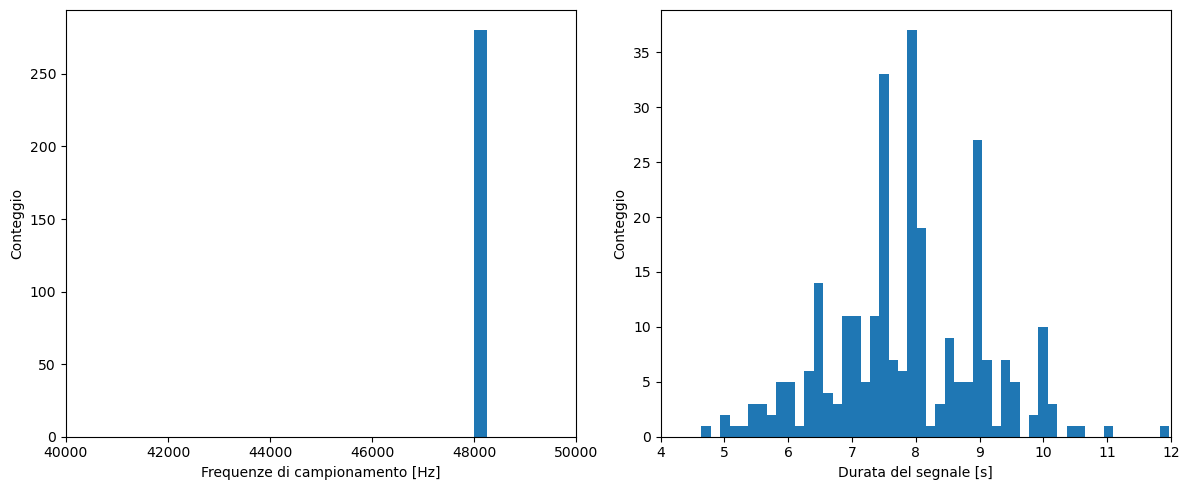

In [3]:
# Per farci un'idea, possiamo verificare al volo la distribuzione dei sampling rates e delle durate dei segnali.


####### A parte che Alice è letteralmente costretta a non salvarli tutti insieme, in realtà è una buona idea per tutti quanti
# quella di leggere una sola nota per il momento. Quando avremo finito di scrivere la parte di codice che riconosce i picchi
# e che da essi calcola la nota suonata, allora poi basterà ricopiare le linee di codice principale dentro un for alla fine,
# oppure tornare qui e reinserire i cicli, tanto ci vogliono 15 minuti a farlo ########################################


# Prima li leggiamo tutti quanti:
all_rates = []
all_lengths = []
for i in range(280): # Vediamo manualmente che nella cartella ci sono 280 file in totale
    filename = "./wav_files/note_{}.wav".format(i+1)
    rate, note = readwav(filename)
    time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) / rate
    all_rates.append(rate)
    all_lengths.append(np.max(time))

# E poi li grafichiamo:
figure, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.hist(all_rates, bins=np.linspace(40000.0, 50000.0, 41))
ax.set_xlabel("Frequenze di campionamento [Hz]")
ax.set_ylabel("Conteggio")
ax.set_xlim(40000.0, 50000.0)
#ax.yaxis.set_label_coords(-0.1, 0.5)
ax = axes[1]
ax.hist(all_lengths, bins=50)
ax.set_xlabel("Durata del segnale [s]")
ax.set_ylabel("Conteggio")
ax.set_xlim(4.0, 12.0)
#ax.yaxis.set_label_coords(-0.1, 0.5)
plt.tight_layout()
plt.show()

# Vedremo dai due grafici come le durate vanno circa dai 4s ai 12s (estremi esclusi), mentre i sampling rates sono TUTTI 48khz.

In [4]:
# Questa cella è per la verifica manuale di tutti gli attack e decay, ovviamente da lasciare commentata.

# L'idea è estremamente semplice: tagliamo il primo X% a tutti i segnali per togliere gli attack, e l'ultimo Y%
# a tutti i segnali per togliere i decay. Non è affatto elegante, ma è veloce, semplice e funziona.

#for i in range(280):
#    filename = "./wav_files/note_{}.wav".format(i+1)
#    rate, note = readwav(filename)
#    time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) / rate
#    first_15 = time[0] + 0.15 * (time[-1] - time[0])
#    last_5 = time[0] + 0.95 * (time[-1] - time[0])
#    plt.figure(figsize=(12,5))
#    plt.plot(time, note[:,0])
#    plt.axvline(x = first_15, color = "r", linestyle = "--")
#    plt.axvline(x = last_5, color = "r", linestyle = "--")
#    plt.show()

# Quello che si può osservare è 15% è esattamente la porzione iniziale da tagliare minima necessaria a coprire TUTTI gli attack.
# La maggior parte dei segnali non sembra avere alcun decay, ma tagliamo l'ultimo 5% per sicurezza.

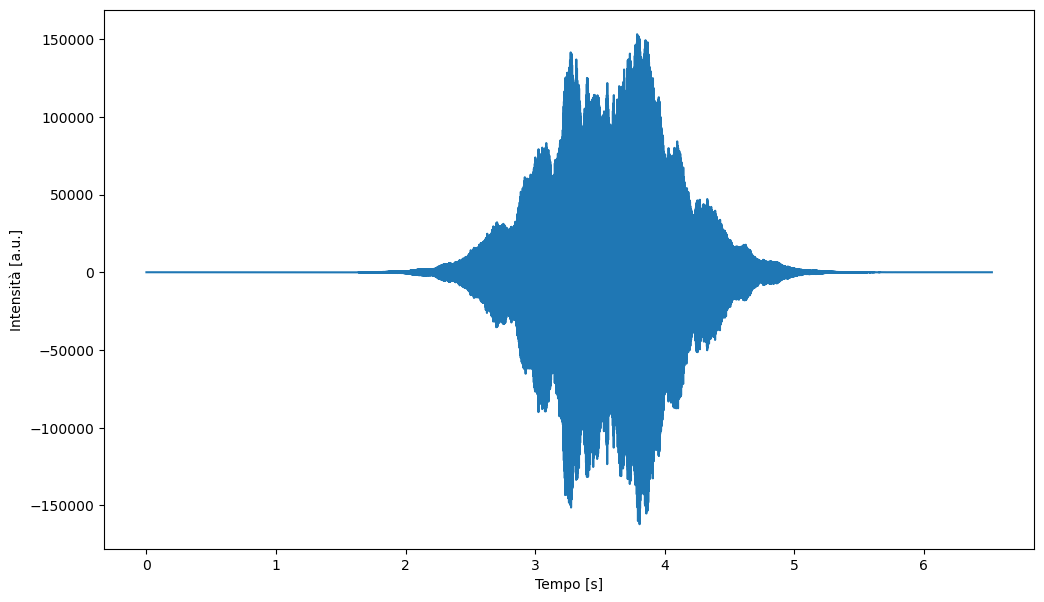

In [5]:
# Anche se tagliassimo nettamente le suddette percentuali, poi dovremmo comunque applicare una funzione finestra al segnale tagliato,
# quindi piuttosto saltiamo lo step intermedio e applichiamo direttamente una funzione finestra che sopprima gli attack.

# Una funzione finestra liscia serve a migliorare i risultati della FFT che faremo dopo; come finestra, scegliamo una campana gaussiana.
# Questa la vorremmo centrata sul segnale tagliato, che corrisponde al 55esimo percentile del segnale non-tagliato: in pratica,
# la spostiamo leggermente più in avanti rispetto al perfetto centro per meglio sopprimere gli attack, ben più lunghi dei decay.
def apply_window(rate, note, sigma):
    sigma *= rate
    N = note.shape[0]
    x = np.arange(N)
    center = 0.55 * N # 0.55 e non 0.50
    window = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    return note * window


########################### Ho cambiato leggermente l'implementazione di gaussian_window, ed in particolare così la sigma
# che passiamo la possiamo scrivere direttamente in secondi così da essere più comprensibile ##############################

######################### Avevamo anche accennato la possibilità di fare una convoluzione nello spazio diretto invece di una
# moltiplicazione, così da avere la moltiplicazione nella FT #####################################################


# Leggiamo un file qualsiasi e proviamo ad applicare la nostra funzione finestra:
filename = "./wav_files/note_104.wav"
rate, note = readwav(filename)
note = note[:,0] # D'ora in poi questo step sarà necessario
time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) / rate
masked_note = apply_window(rate, note, sigma = 0.5)
# dove la sigma va specificata in secondi. Ricorda però che i segnali più brevi sono lunghi solo 4s quindi la sigma,
# se uguale per tutti i segnali, non può andare oltre il mezzo secondo.


###################### Già 280 * 300k sono parecchie cose da salvare in memoria tutte in una sola volta, ma moltiplicare
# ulteriormente per due perché non si vogliono sovrascrivere i dati originali con quelli mascherati non mi sembra saggio.
# Ora qui io l'ho fatto, soprattutto per i subplot che verranno, ma dico per il futuro ##############


# Grafichiamo per vedere se ha funzionato come previsto:
plt.figure(figsize=(12, 7))
plt.plot(time, masked_note)
plt.xlabel("Tempo [s]")
plt.ylabel("Intensità [a.u.]")
plt.show()

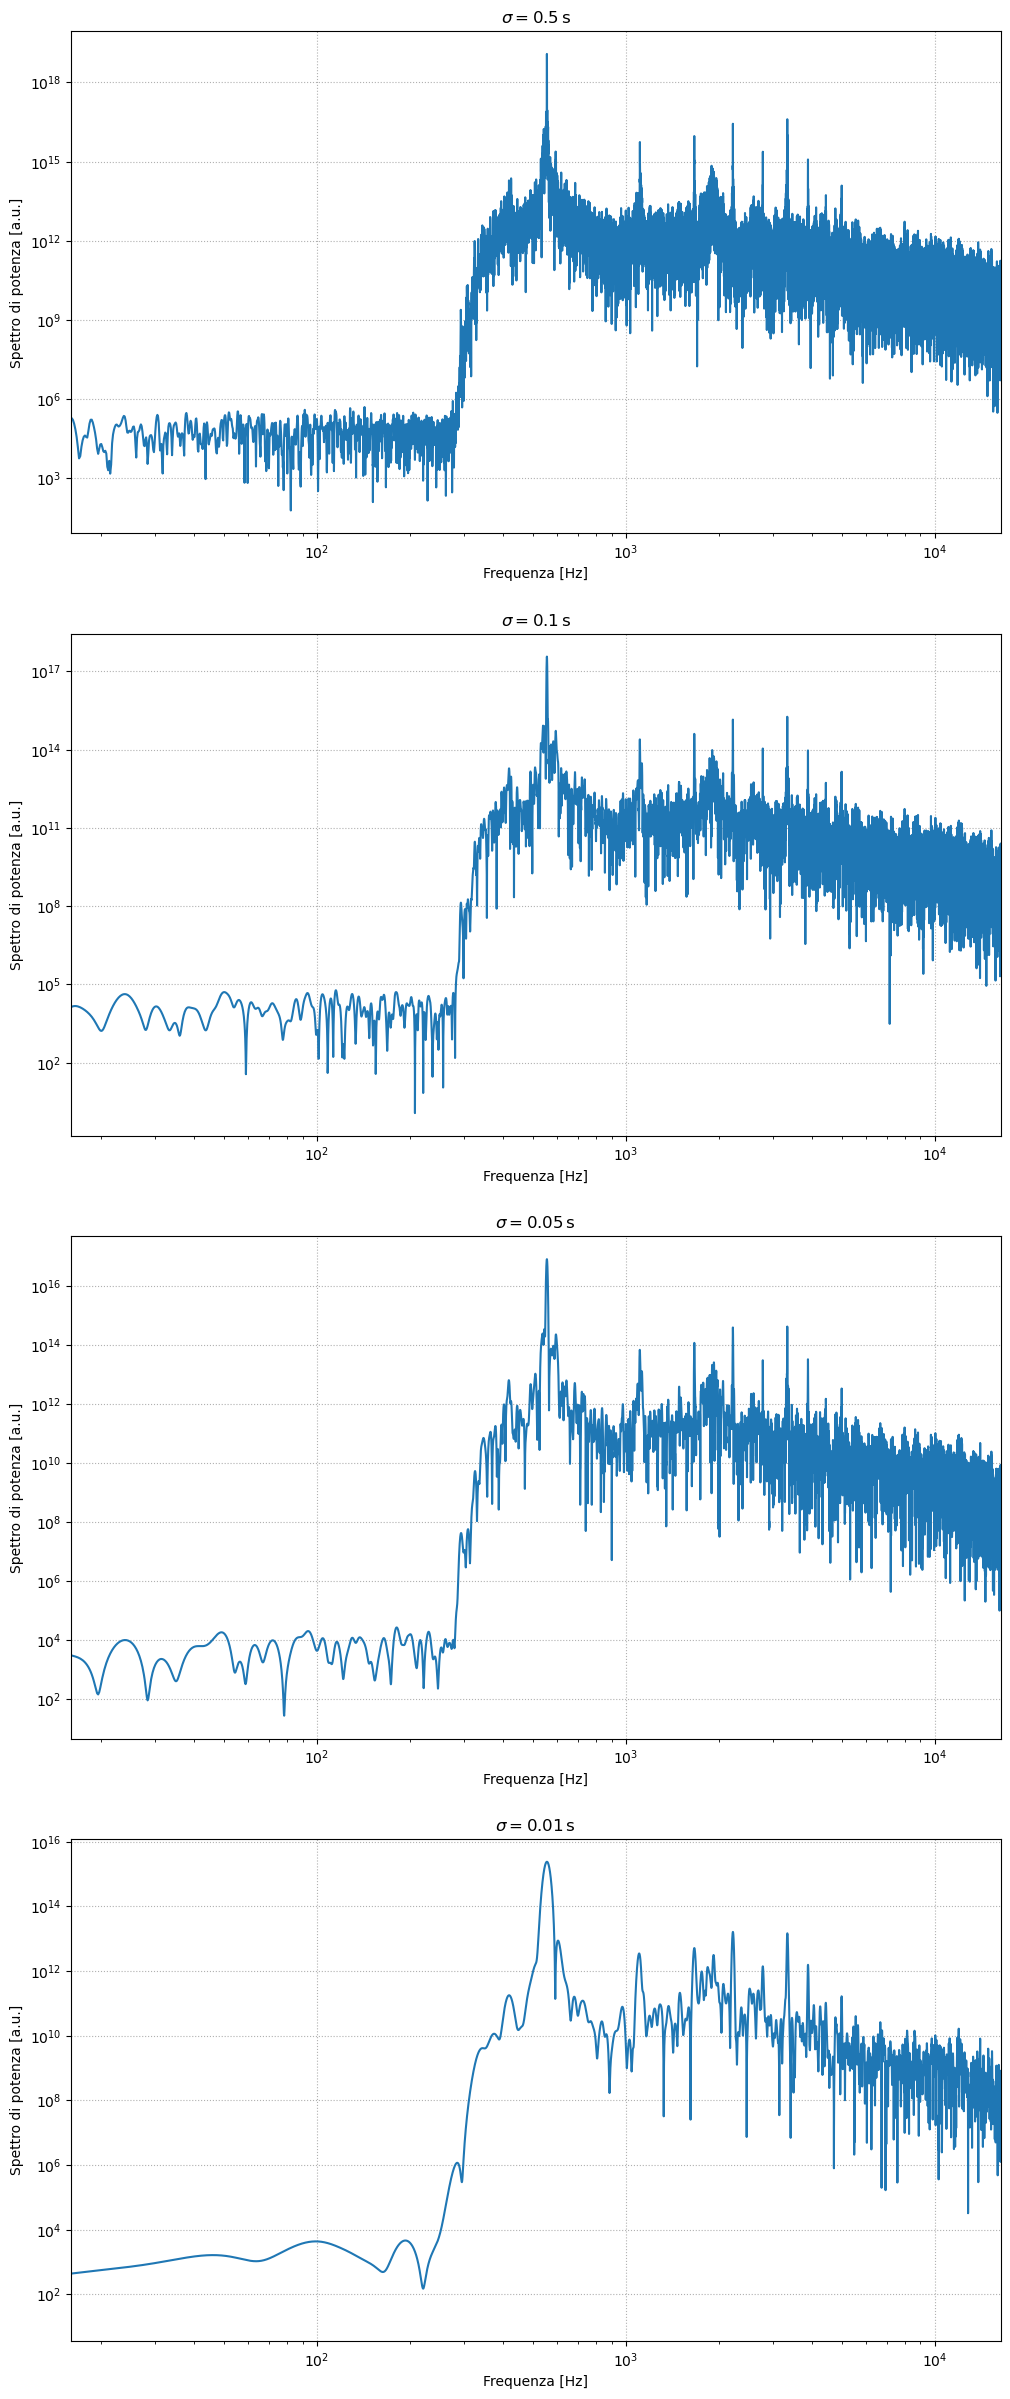

In [6]:
################## Altro esempio di sanity check che probabilmente diventerà una cella commentata #################


# Oltre ad eseguire per la prima volta la FFT del segnale mascherato, vogliamo fare un confronto qualitativo per vedere
# cosa succede a suddetta FFT quando variamo il valore di sigma della funzione finestra:
decreasing_sigmas = [0.5, 0.1, 0.05, 0.01]
figure, axes = plt.subplots(4, 1, figsize=(12, 30))
#figure.subplots_adjust(hspace = 0.35)
for i in range(4):
    masked_note = apply_window(rate, note, sigma=decreasing_sigmas[i])
    y = scipy.fft.rfft(masked_note)
    y = np.abs(y)**2
    x = scipy.fft.rfftfreq(masked_note.shape[0], d=1/rate)
    ax = axes[i]
    ax.plot(x, y)
    ax.set_yscale("log", base=10)
    #ax.set_xscale("log", base=2)
    ax.set_xscale("log", base=10)
    ax.set_title("$\sigma = {}\,$s".format(decreasing_sigmas[i]))
    ax.set_xlim(2**4, 2**14)
    ax.set_ylabel("Spettro di potenza [a.u.]")
    ax.set_xlabel("Frequenza [Hz]")
    ax.grid(linestyle = ":")
    #ax.yaxis.set_label_coords(-0.1, 0.5)
#axes[-1].set_xlabel("Frequenza [Hz]")
plt.show()
# Come possiamo vedere, restringere la sigma ha l'effetto di "diramare" il rumore bianco, senza necessariamente ridurne l'ampiezza.

In [7]:
##################### Da qui inizio a provare a fare merging del lavoro di Alice sul suo notebook.
# Potrei aver riportato o interpretato male delle cose, e non sarà commentato bene come il resto dato che non è il mio lavoro.
# Spero Alice possa riprendere da qui. Ammetto di non aver capito cosa faccia ###################################


rate, note = readwav('./wav_files/note_1.wav')
note = note[:, 0]
sigma = 1000 / rate ######### correzione dovuta alla mia riscrittura della funzione, questi sono circa 0.02 secondi
masked_note = apply_window(rate, note, sigma)

# faccio scorrere la finestra gaussiana e calcolo la media per rimuovere il rumore bianco
window_size = 1000  # dimensione della finestra
step_size = 500     # passo di scorrimento
smoothed_signal = np.zeros_like(masked_note)
for i in range(0, len(masked_note) - window_size, step_size):
    window = masked_note[i:i+window_size]
    smoothed_signal[i:i+window_size] += window / (window_size / step_size)

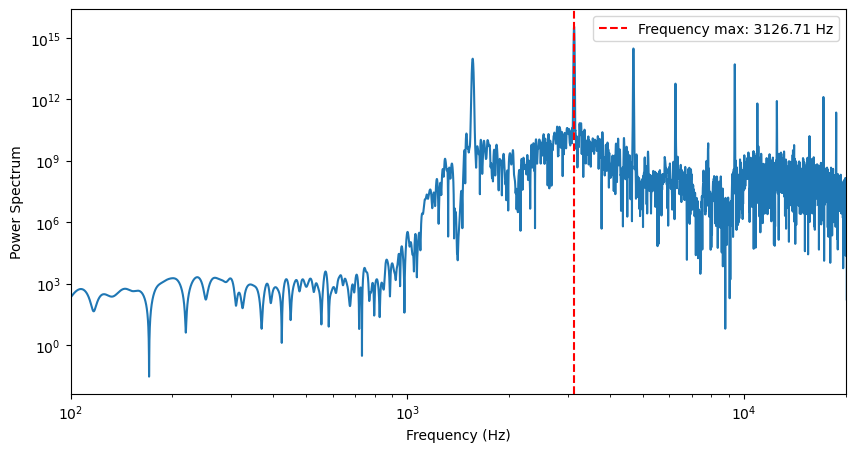

In [8]:
# calcoliamo il power spectrum
fft = scipy.fft.rfft(masked_note)
power_spectra = np.abs(fft)**2

#calcolo frequenze corrispondenti
frequencies = scipy.fft.rfftfreq(masked_note.shape[0], d=1/rate)

# Plot dello spettro di potenza del primo segnale mascherato
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, power_spectra)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")

#limito x
plt.xlim(100, 20000)

# evidenziamo la frequenza fondamentale
freq_max = frequencies[np.argmax(power_spectra)]
plt.axvline(freq_max, color='r', linestyle='--', label=f'Frequency max: {freq_max:.2f} Hz')
plt.legend()

plt.show()

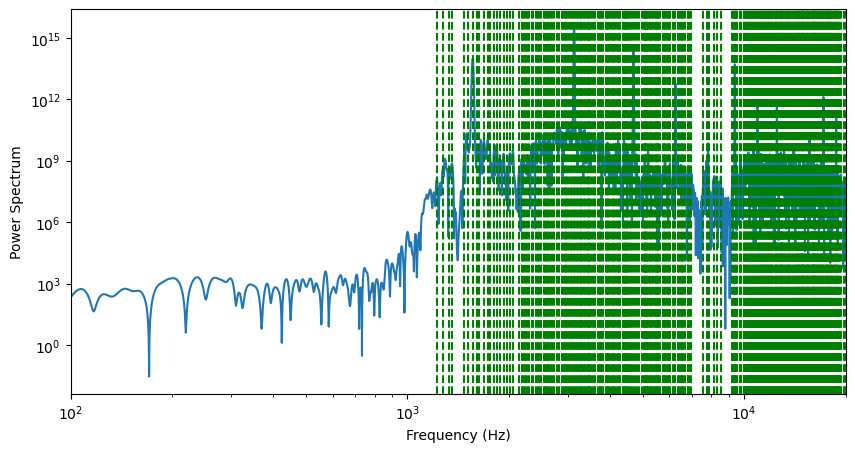

In [9]:
# identifichiamo i picchi per la frequenza fondamentale e le armoniche
# potrebbe essere che la frequenza fondamentale non sia il picco più alto, quindi dobbiamo cercare i picchi e poi identificare la frequenza fondamentale in base alla distanza tra i picchi
from scipy.signal import find_peaks
peaks, _ = find_peaks(power_spectra, prominence= 10**8) # troviamo i picchi che sono almeno lo 0.1% del picco massimo

#inserisco una tolleranza per identificare la frequenza fondamentale, in modo da escludere picchi che sono troppo vicini tra loro
tolerance = 20 # in Hz
fundamental_freqs = []
for peak in peaks:
    freq = frequencies[peak]
    if all(abs(freq - f) > tolerance for f in fundamental_freqs):
        fundamental_freqs.append(freq)

    freq_max = frequencies[np.argmax(power_spectra)]

# evidenziamo i picchi sul grafico
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, power_spectra)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.xlim(100, 20000)
for f in fundamental_freqs:
    plt.axvline(f, color='g', linestyle='--')
plt.show()